In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
from scipy import stats
import os
import sys
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import numpy.testing as npt

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [4]:
font_files = ["font_type/Times New Roman.ttf", "font_type/Times New Roman Bold.ttf", 
              "font_type/Times New Roman Italic.ttf", "font_type/Times New Roman Bold Italic.ttf"]

for font_file in font_files:
    if os.path.exists(font_file):
        fm.fontManager.addfont(font_file)
        
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

In [6]:
def group_by_score_ranges(data_list):
    ranges = {
        1.0: [],           # exactly 1.0
        '[0.9,1.0)': [],   # >= 0.9 and < 1.0
        '[0.8,0.9)': [],   # >= 0.8 and < 0.9
        '[0.7,0.8)': [],   # >= 0.7 and < 0.8
        '[0.6,0.7)': [],   # >= 0.6 and < 0.7
        '[0.5,0.6)': [],   # >= 0.5 and < 0.6
        '[0.4,0.5)': [],   # >= 0.4 and < 0.5
        '[0.3,0.4)': [],   # >= 0.3 and < 0.4
        '[0.2,0.3)': [],   # >= 0.2 and < 0.3
        '[0.1,0.2)': [],   # >= 0.1 and < 0.2
        '(0.0,0.1)': [],   # > 0.0 and < 0.1
        0.0: []            # exactly 0.0
    }
    
    for item in data_list:
        score = item[2]
        
        if score == 1.0:
            ranges[1.0].append(item)
        elif score >= 0.9:
            ranges['[0.9,1.0)'].append(item)
        elif score >= 0.8:
            ranges['[0.8,0.9)'].append(item)
        elif score >= 0.7:
            ranges['[0.7,0.8)'].append(item)
        elif score >= 0.6:
            ranges['[0.6,0.7)'].append(item)
        elif score >= 0.5:
            ranges['[0.5,0.6)'].append(item)
        elif score >= 0.4:
            ranges['[0.4,0.5)'].append(item)
        elif score >= 0.3:
            ranges['[0.3,0.4)'].append(item)
        elif score >= 0.2:
            ranges['[0.2,0.3)'].append(item)
        elif score >= 0.1:
            ranges['[0.1,0.2)'].append(item)
        elif score > 0.0:  # > 0.0 and < 0.1
            ranges['(0.0,0.1)'].append(item)
        else:  # score == 0.0
            ranges[0.0].append(item)
    
    return ranges



In [7]:
model_lst = [
    # 'Qwen/Qwen2.5-1.5B-Instruct',
    'Qwen/Qwen2.5-3B-Instruct',
    'Qwen/Qwen2.5-7B-Instruct',
    'Qwen/Qwen2.5-72B-Instruct-Turbo',
    'Qwen/Qwen3-4B',
    'Qwen/Qwen3-8B',
    'Qwen/Qwen3-32B',
    'google/gemma-2-2b-it',
    'google/gemma-2-9b-it',
    'google/gemma-2-27b-it',
    'gpt-4o',
    # 'meta-llama/Llama-3.2-1B-Instruct',
    'meta-llama/Llama-3.2-3B-Instruct',
    'meta-llama/Llama-3.1-8B-Instruct',
    'meta-llama/Llama-3.3-70B-Instruct-Turbo',
    'mistralai/Ministral-8B-Instruct-2410',
    'mistralai/Mistral-Small-24B-Instruct-2501'
    #'Qwen/Qwen3-8B_thinking'
]

In [8]:
bin_model_key='mean_across_models'
filter_model_data_gen_diff = np.load('/mnt/ssd2/yefan/llm-verify-dynamics/generator_data/math/model_gen_diff_math.npy', allow_pickle=True).item()
filter_model_data_gen_diff_dict = {}

for model_name, tuple_list in filter_model_data_gen_diff.items():
    # Convert list of tuples to dictionary
    # Key: (first_item, second_item), Value: third_item
    filter_model_data_gen_diff_dict[model_name] = {(item[0], item[1]): item[2] for item in tuple_list}

# print(filter_model_data_gen_diff.keys())
sorted_list_desc = sorted(filter_model_data_gen_diff[bin_model_key], key=lambda x: x[2], reverse=True)
grouped_data = group_by_score_ranges(sorted_list_desc)

In [9]:
benchmark_path='/mnt/ssd2/yefan/llm-verify-dynamics/verifier_data'
judge_acc_dict = {}
for model_key in model_lst:
    path = f"{benchmark_path}/{model_key}/single_verification/temp0.0_topp1.0_seqs1/vanilla/math_balanced_subsample_4_metrics.npy"
    judge_data_all = np.load(path, allow_pickle=True).item()
    judge_acc_dict[model_key] = judge_data_all

[0.1,0.3): Pearson r=0.842, Linear R²=0.710, LOWESS R²=0.854
  Linearity assessment: NONLINEAR
[0.4,0.5): Pearson r=0.947, Linear R²=0.897, LOWESS R²=0.901
  Linearity assessment: LINEAR
[0.8,0.9): Pearson r=0.696, Linear R²=0.484, LOWESS R²=0.882
  Linearity assessment: NONLINEAR


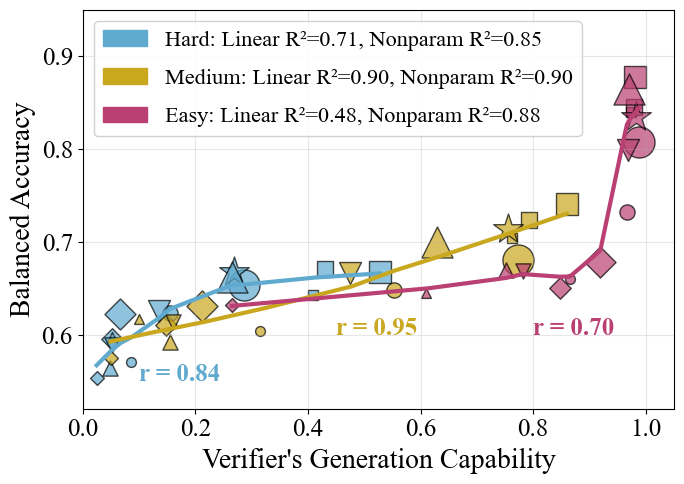

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from matplotlib.patches import Patch
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import interpolate
from scipy.stats import pearsonr

acc_metric = 'balanced_accuracy_half'
lowess_frac = 0.6  # Smoothing parameter for LOWESS

# Keep all your existing helper functions unchanged
def get_model_info(model_name):
    if 'Qwen2.5' in model_name:
        family = 'Qwen2.5'
    elif 'Qwen3' in model_name:
        family = 'Qwen3'
    elif 'Llama' in model_name:
        family = 'Llama'
    elif 'gemma' in model_name:
        family = 'Gemma'
    elif 'mistral' in model_name or 'Mistral' in model_name:
        family = 'Mistral'
    elif 'gpt' in model_name:
        family = 'GPT'
    else:
        family = 'Other'
    
    size_match = re.search(r'(\d+(?:\.\d+)?)[bBM]', model_name)
    if size_match:
        size_value = float(size_match.group(1))
        size_unit = size_match.group(0)[-1].upper()
        if size_unit == 'M':
            size_value = size_value / 1000
        size_str = size_match.group(1) + size_match.group(0)[-1]
    else:
        size_value = 100
        size_str = model_name.split('/')[-1] if '/' in model_name else model_name
    
    return family, size_str, size_value

family_markers = {
    'Qwen2.5': 'o',
    'Qwen3': 's',
    'Llama': '^',
    'Gemma': 'D',
    'Mistral': 'v',
    'GPT': '*',
    'Other': 'p'
}

def get_marker_size(size_value):
    if size_value >= 1 and size_value <= 4:
        return 50
    elif size_value > 4 and size_value <= 9:
        return 120
    elif size_value > 9 and size_value <= 32:
        return 250
    else:
        return 500

# Add the unified fitting function
def unified_fit_and_assess(X, y, x_grid, method='lowess', lowess_frac=0.65):
    """
    Unified fitting with LOWESS and linear comparison
    """
    results = {}
    
    # Calculate Pearson correlation
    pearson_r, pearson_p = pearsonr(X.ravel(), y)
    results['pearson'] = {'r': pearson_r, 'p_value': pearson_p}
    
    # Linear fit for comparison
    lin = LinearRegression()
    lin.fit(X.reshape(-1, 1), y)
    y_pred_lin = lin.predict(X.reshape(-1, 1))
    y_grid_lin = lin.predict(x_grid.reshape(-1, 1))
    r2_lin = r2_score(y, y_pred_lin)
    
    results['linear'] = {
        'y_grid': y_grid_lin,
        'r2': r2_lin,
        'y_pred': y_pred_lin
    }
    
    # LOWESS fitting
    lowess_result = lowess(y, X.ravel(), frac=lowess_frac, return_sorted=False)
    lowess_interp = interpolate.interp1d(
        X.ravel(), lowess_result, 
        kind='linear', fill_value='extrapolate'
    )
    y_grid_lowess = lowess_interp(x_grid.ravel())
    r2_lowess = r2_score(y, lowess_result)
    
    results['lowess'] = {
        'y_grid': y_grid_lowess,
        'r2': r2_lowess,
        'y_pred': lowess_result
    }
    
    # Assess linearity
    results['linearity_assessment'] = {
        'is_linear': abs(r2_lowess - r2_lin) < 0.05,
        'r2_difference': r2_lowess - r2_lin
    }
    
    return results

# Main plotting code - ADAPTED VERSION
smallest_range = '[0.1,0.3)'   # hard
largest_range  = '[0.8,0.9)'   # easy
middle_range   = '[0.4,0.5)'   # medium

range_colors = {
    smallest_range: "#60aacf",  # Blue
    middle_range:   "#c9a71f",  # Yellow
    largest_range:  "#ba4073",  # Red
}

plt.figure(figsize=(7, 5))

fit_handles = []  # collect line handles for legend
pearson_values = {}
# Loop over difficulty ranges
for diff_range in [smallest_range, middle_range, largest_range]:
    # Collect data (keep your existing code)
    x_values, y_values = [], []
    model_families, model_sizes, model_size_values = [], [], []
    
    for model_key in model_lst:
        mean_over_samples_diff, mean_over_samples_judge = [], []
        
        if diff_range == '[0.1,0.3)':
            for diff_range_sub in ['[0.1,0.2)', '[0.2,0.3)']:
                for dataset_name, dataset_idx, diff in grouped_data[diff_range_sub]:
                    mean_over_samples_diff.append(filter_model_data_gen_diff_dict[model_key][(dataset_name, dataset_idx)])
                    mean_over_samples_judge.append(judge_acc_dict[model_key][(dataset_name, dataset_idx)][acc_metric])
        else:
            for dataset_name, dataset_idx, diff in grouped_data[diff_range]:
                mean_over_samples_diff.append(filter_model_data_gen_diff_dict[model_key][(dataset_name, dataset_idx)])
                mean_over_samples_judge.append(judge_acc_dict[model_key][(dataset_name, dataset_idx)][acc_metric])
        
        if mean_over_samples_diff:
            x_values.append(np.nanmean(mean_over_samples_diff))
            y_values.append(np.nanmean(mean_over_samples_judge))
            family, size_str, size_value = get_model_info(model_key)
            model_families.append(family)
            model_sizes.append(size_str)
            model_size_values.append(size_value)
    
    # Scatter plot (keep as is)
    for i in range(len(x_values)):
        family = model_families[i]
        marker_size = get_marker_size(model_size_values[i])
        plt.scatter(
            x_values[i], y_values[i],
            marker=family_markers[family],
            c=range_colors[diff_range],
            s=marker_size,
            alpha=0.7,
            edgecolors='black',
            linewidth=1,
            label="_nolegend_"
        )
    
    # --- REVISED FIT CURVES using unified approach ---
    if len(x_values) > 3:
        X = np.array(x_values)
        y = np.array(y_values)
        
        # Create grid for smooth curves
        x_min, x_max = np.min(X), np.max(X)
        x_grid = np.linspace(x_min, x_max, 200)
        
        # Apply unified fitting
        fit_results = unified_fit_and_assess(X, y, x_grid, method='lowess', lowess_frac=lowess_frac)
        
        # Get R² and Pearson r values
        r2_lowess = fit_results['lowess']['r2']
        r2_linear = fit_results['linear']['r2']
        pearson_r = fit_results['pearson']['r']
        
        # Decide which fit to show based on linearity assessment
        # Option 1: Always use LOWESS for consistency
        line, = plt.plot(
            x_grid, fit_results['lowess']['y_grid'],
            color=range_colors[diff_range],
            linestyle="-", linewidth=3
        )
        if diff_range == smallest_range:
            label = f"Hard: Linear R²={r2_linear:.2f}, Nonparam R²={r2_lowess:.2f}"
        elif diff_range == middle_range:
            label = f"Medium: Linear R²={r2_linear:.2f}, Nonparam R²={r2_lowess:.2f}"
        else:
            label = f"Easy: Linear R²={r2_linear:.2f}, Nonparam R²={r2_lowess:.2f}"

        patch = Patch(color=range_colors[diff_range])
        
        fit_handles.append((patch, label))

        print(f"{diff_range}: Pearson r={pearson_r:.3f}, Linear R²={r2_linear:.3f}, LOWESS R²={r2_lowess:.3f}")
        print(f"  Linearity assessment: {'LINEAR' if fit_results['linearity_assessment']['is_linear'] else 'NONLINEAR'}")
        pearson_values[diff_range] = pearson_r
# Axis labels, grid (keep as is)

plt.text(0.1, 0.55, f'r = {pearson_values[smallest_range]:.2f}', 
         color=range_colors[smallest_range], fontsize=18, fontweight='bold')
plt.text(0.45, 0.6, f'r = {pearson_values[middle_range]:.2f}', 
         color=range_colors[middle_range], fontsize=18, fontweight='bold')
plt.text(0.8, 0.6, f'r = {pearson_values[largest_range]:.2f}', 
         color=range_colors[largest_range], fontsize=18, fontweight='bold')


plt.xlabel("Verifier's Generation Capability", fontsize=20)
plt.ylabel("Balanced Accuracy", fontsize=20)
plt.grid(True, alpha=0.3)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim([0, 1.05])
plt.ylim([0.52, 0.95])
plt.yticks([0.6, 0.7, 0.8, 0.9], fontsize=18)

fit_lines, fit_labels = zip(*fit_handles)
plt.legend(fit_lines, fit_labels, 
           loc="upper left", 
           fontsize=16, 
           title_fontsize=14, 
           labelspacing=0.8,
           framealpha=0.9)
plt.tight_layout()
# plt.savefig("figures_draft/verifier_capability/difficulty_comparison_0.1-0.3_vs_0.4-0.5_nonparam_linear_fit.pdf",
#             dpi=300, bbox_inches="tight")
plt.show()